# 13 - Feature Scaling and Weight Distributions

**Section:** FNNs | **Prereqs:** `FNNs/MNISToptimizers.ipynb` | **Next:** `FNNs/ScrambledMNIST.ipynb`

Two ideas in one notebook.

**1. Scale the inputs.** Raw MNIST pixels are 0-255. Feeding numbers that large
into a network makes the first layer's activations huge, which makes gradients
huge, which makes training unstable at any sane learning rate. `MinMaxScaler`
squashes every feature to [0,1] and the same architecture trains noticeably
better. Rule: inputs should be roughly zero-centred and order-1.

**2. Look at the weights.** Histogram the first layer before and after training.
Initialisation is a narrow symmetric band (PyTorch's default Kaiming-uniform);
training spreads it out. That histogram is a live diagnostic - all-zero weights
mean dead units, exploding weights mean the learning rate is too high.
`Weight Initialization/` is built on this idea.

**The scaling rule:** `fit_transform` on train, `transform` on test. The scaler
*learns* the min and max from whatever you fit it on, so fitting it on the test
set leaks test statistics into your pipeline. Every notebook from here on follows
this order.

In [47]:
# torchinfo gives a per-layer parameter summary (the maintained successor to
# torchsummary).
!pip install torchinfo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
from torchinfo import summary

In [48]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

In [49]:
# Flatten to 784. Values are still raw 0-255 at this point.
label = data.targets.to('cuda')
data = data.data.view(-1,784).float()

test_label = test_data.targets.to('cuda')
test_data = test_data.data.view(-1,784).float()

In [50]:
# MinMaxScaler maps each feature to [0,1] using the min and max it saw during
# fit(). sklearn works on numpy, so this returns arrays, not tensors.
# Scaling data from 0 to 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [51]:
# transform(), NOT fit_transform(): the test set is scaled with the statistics
# the scaler learned from TRAINING data. Re-fitting here would let test-set
# min/max leak into the pipeline. Anything a preprocessing step learns must be
# learned from the training split only.
test_data = scaler.transform(test_data)

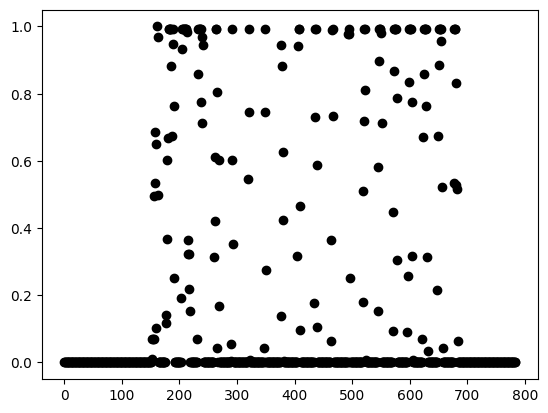

In [52]:
# Pixel values after scaling: all within [0,1] instead of [0,255].
plt.plot(data[0], "ko");

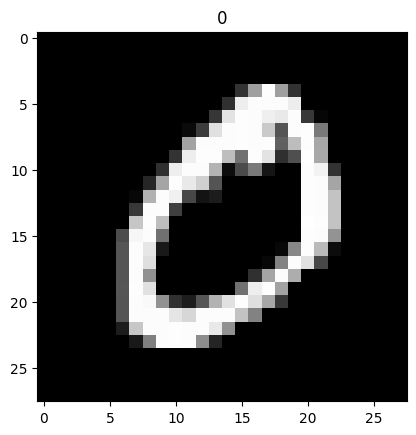

In [53]:
# The image is unchanged apart from the scale - scaling is a change of units,
# not of content.
plt.imshow(np.reshape(data[1], (28,28)),cmap='gray')
plt.title(label[1].item());

In [54]:
# Back to tensors on the GPU. sklearn returns float64; the cast to float32
# matters, since PyTorch layers default to float32 and will refuse to mix.
data = torch.tensor(data,device='cuda',dtype=torch.float)
test_data = torch.tensor(test_data,device='cuda',dtype=torch.float)

In [55]:
# Standard loaders.
train_data = TensorDataset(data,label)
test_data = TensorDataset(test_data,test_label)

bs = 32
data_loader = DataLoader(train_data, batch_size=bs, drop_last=True, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [56]:
# 784-128-64-32-10, raw logits out, to pair with CrossEntropyLoss.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 128)

    self.fc1 = nn.Linear(128,64)

    self.fc2 = nn.Linear(64,32)

    self.output_layer = nn.Linear(32,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return self.output_layer(x)

In [65]:
# Collect every weight in the network into one flat vector, for histogramming.
# np.concatenate takes a SEQUENCE of arrays, so build the list first.
def getWeights(net):
  return np.concatenate([p.detach().flatten().cpu().numpy()
                         for name, p in net.named_parameters() if 'weight' in name])


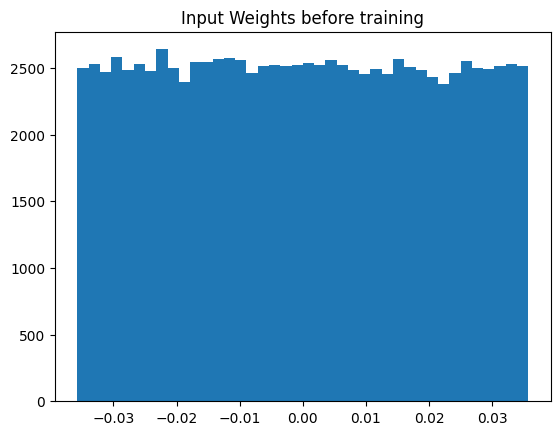

In [57]:
# Weight histogram BEFORE training. PyTorch initialises Linear layers from a
# uniform distribution of width 1/sqrt(fan_in) - symmetric, centred on zero, and
# narrow. Everything a model knows starts here.
classifier = model().to('cuda')

plt.hist(classifier.input_layer.weight.detach().flatten().cpu(), 40)
plt.title("Input Weights before training");

In [58]:
# The usual training function. It builds its own model, so re-running this cell
# restarts training from fresh weights instead of continuing the previous run -
# which is what makes repeated runs comparable.
def train_model():

  classifier = model().to('cuda')

  epochs = 100
  lr = 0.0001

  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)


  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in data_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat,dim = 1) == y).float()).cpu() )

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    if i % 10 == 0 or i == epochs-1:
      print(f"Epoch {i} : Loss = {losses[i].item()}")

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      Preds = torch.argmax(classifier(X), dim = 1)
      test_acc.append( 100 * torch.mean( (Preds == Y).float()) )


  return losses, train_acc, test_acc, classifier


In [59]:
losses, train_acc, test_acc, classifier = train_model()

Epoch 0 : Loss = 0.8251392245292664
Epoch 10 : Loss = 0.1098562702536583
Epoch 20 : Loss = 0.05896687135100365
Epoch 30 : Loss = 0.03301341086626053
Epoch 40 : Loss = 0.017731836065649986
Epoch 50 : Loss = 0.008118451572954655
Epoch 60 : Loss = 0.004399098921567202
Epoch 70 : Loss = 0.0013945717364549637
Epoch 80 : Loss = 0.0011867793509736657
Epoch 90 : Loss = 0.001511799986474216
Epoch 99 : Loss = 0.0028830943629145622


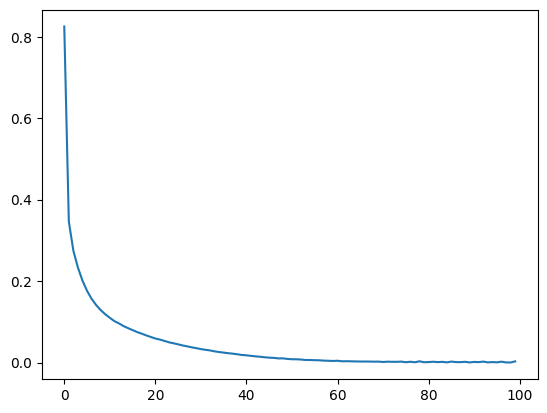

In [60]:
# Loss curve.
plt.plot(losses);

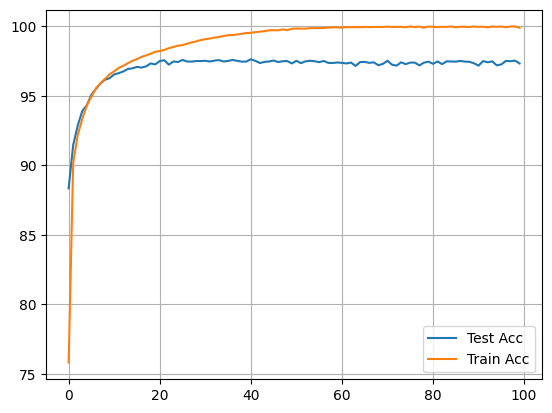

In [61]:
# Train vs test accuracy - compare with the unscaled run in MNIST.ipynb.
test_acc = [i.cpu() for i in test_acc]

plt.plot(test_acc,label="Test Acc")
plt.plot(train_acc, label="Train Acc")
plt.grid()
plt.legend();

In [62]:
# Final numbers.
test_acc[-1], train_acc[-1]

(tensor(97.3400), np.float32(99.91333))

In [63]:
# Per-layer parameter counts. Most of the parameters sit in the first layer
# (784*128), which is typical of fully connected nets on images and part of why
# CNNs are so much more efficient.
summary(classifier)

Layer (type:depth-idx)                   Param #
model                                    --
├─Linear: 1-1                            100,480
├─Linear: 1-2                            8,256
├─Linear: 1-3                            2,080
├─Linear: 1-4                            330
Total params: 111,146
Trainable params: 111,146
Non-trainable params: 0

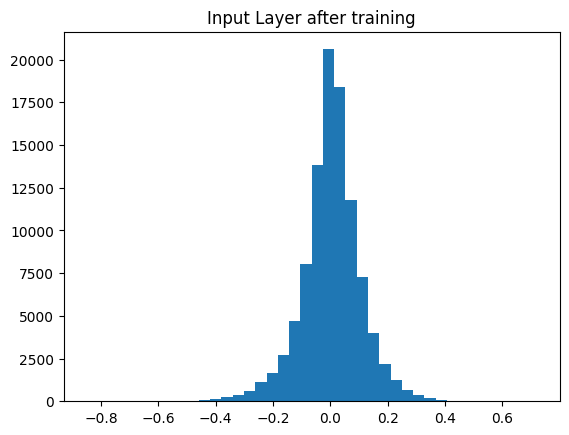

In [64]:
# Weight histogram AFTER training - compare against the 'before' plot above:
# training widens the distribution as weights specialise.
plt.hist(classifier.input_layer.weight.detach().flatten().cpu(), 40);
plt.title("Input Layer after training");